# Headline result — projection_threshold = 0.00

The main finding from the PP-B schedule (project_every=25, relax_steps=32) is: allowing reconstruction outside the strict support (i.e. setting `projection_threshold = 0.00`) markedly improves 3D reconstruction metrics. This compact notebook reproduces the summary, shows the sweep table from CHECKLIST.md, and attempts to load the precomputed chosen result if available.

In [ ]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import unxt as u
from libertem_holo.base.mbir import load_vortex_disc_fixture, plot_m_slices, support_center_yx

In [10]:
# Load the cached 32^3 fixture
fixture = load_vortex_disc_fixture(32)
rho_true = np.asarray(fixture['rho_true'], dtype=np.float32)
m_true = np.asarray(fixture['m_true'], dtype=np.float32)
phi_true = np.asarray(fixture['phi_true'], dtype=np.float32)
pixel_size = u.Quantity(float(fixture['pixel_size_nm']), 'nm')
yx_center = support_center_yx(rho_true)
print('Loaded fixture: shapes', rho_true.shape, m_true.shape, phi_true.shape, 'center', yx_center)

Loaded fixture: shapes (32, 32, 32) (32, 32, 32, 3) (32, 32) center (16, 16)


In [11]:
# RUN: deterministic PP-B reconstruction from a hard zero start
import os, numpy as np
import neuralmag as nm
from libertem_holo.base.mbir.inversion import invert_magnetization_physics_projected
# Prepare fixture arrays
rho = np.asarray(fixture['rho_true'], dtype=np.float32)
phi_arr = np.asarray(fixture['phi_true'], dtype=np.float32)
# Run PP-B from a deliberately hard initialization
max_iter = 60
result = invert_magnetization_physics_projected(
    phi_arr,
    rho,
    pixel_size=pixel_size,
    max_iter=max_iter,
    lr=1e-3,
    init='zero',
    project_every=10,
    relax_steps=64,
    projection_threshold=0.0,
    ms_a_per_m=8e5,
    a_j_per_m=1.3e-11,
)
# Save artifact
art_dir = os.path.join(os.path.dirname(os.getcwd()), 'artifacts')
os.makedirs(art_dir, exist_ok=True)
artifact_path = os.path.join(art_dir, 'chosen_result_projection_threshold_0.00_run.npz')
np.savez_compressed(artifact_path, chosen_result={'m_recon': np.asarray(result.m_recon), 'phi_pred': np.asarray(result.phi_pred), 'loss_history': np.asarray(result.loss_history)})
chosen_result = {'m_recon': np.asarray(result.m_recon), 'phi_pred': np.asarray(result.phi_pred), 'loss_history': np.asarray(result.loss_history)}
print('PP-B run complete; artifact saved to', artifact_path)

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:139: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val = jnp.asarray(coeff.value, dtype=dtype)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:159: UserWarning: Explicitl

PP-B run complete; artifact saved to /Users/landers/LiberTEM-holo/notebooks/MBIR/artifacts/chosen_result_projection_threshold_0.00_run.npz


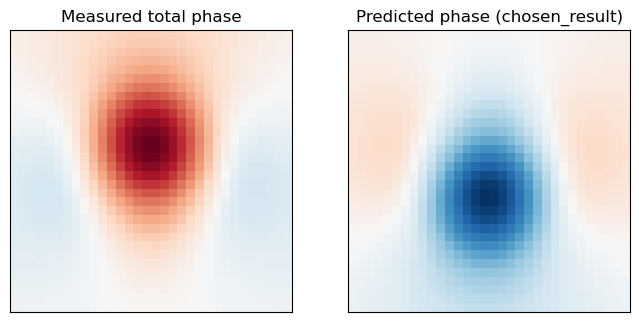

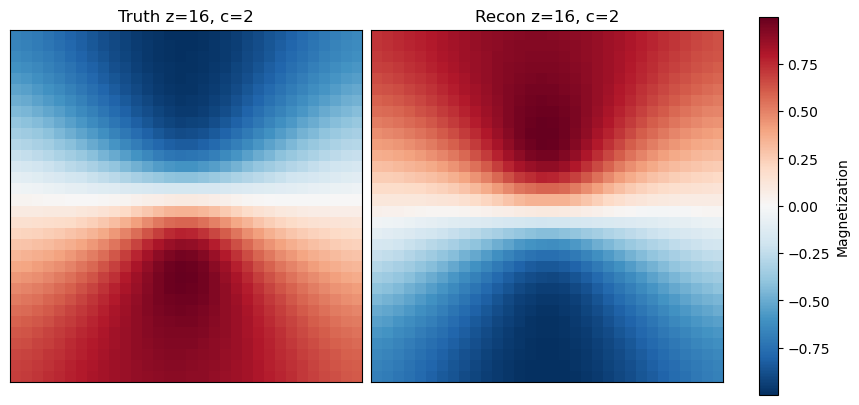

In [12]:
# If chosen_result is available, plot the phase fit and a small slice gallery.
if chosen_result is None:
    print('No chosen result to plot.')
else:
    phi_pred = chosen_result.get('phi_pred')
    phi_meas = phi_true if 'phi_true' in globals() else None
    if phi_pred is not None and phi_meas is not None:
        vmax = max(np.max(np.abs(phi_meas)), np.max(np.abs(phi_pred)))
        fig, ax = plt.subplots(1,2, figsize=(8,4))
        ax[0].imshow(phi_meas, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax[0].set_title('Measured total phase')
        ax[1].imshow(phi_pred, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax[1].set_title('Predicted phase (chosen_result)')
        for a in ax: a.set_xticks([]); a.set_yticks([])
        plt.show()
    m_recon = chosen_result.get('m_recon')
    if m_recon is not None and plot_m_slices is not None:
        plot_m_slices(m_recon, m_true=m_true)
    elif m_recon is not None:
        print('Reconstruction available (m_recon), but plotting helper is unavailable in this environment.')

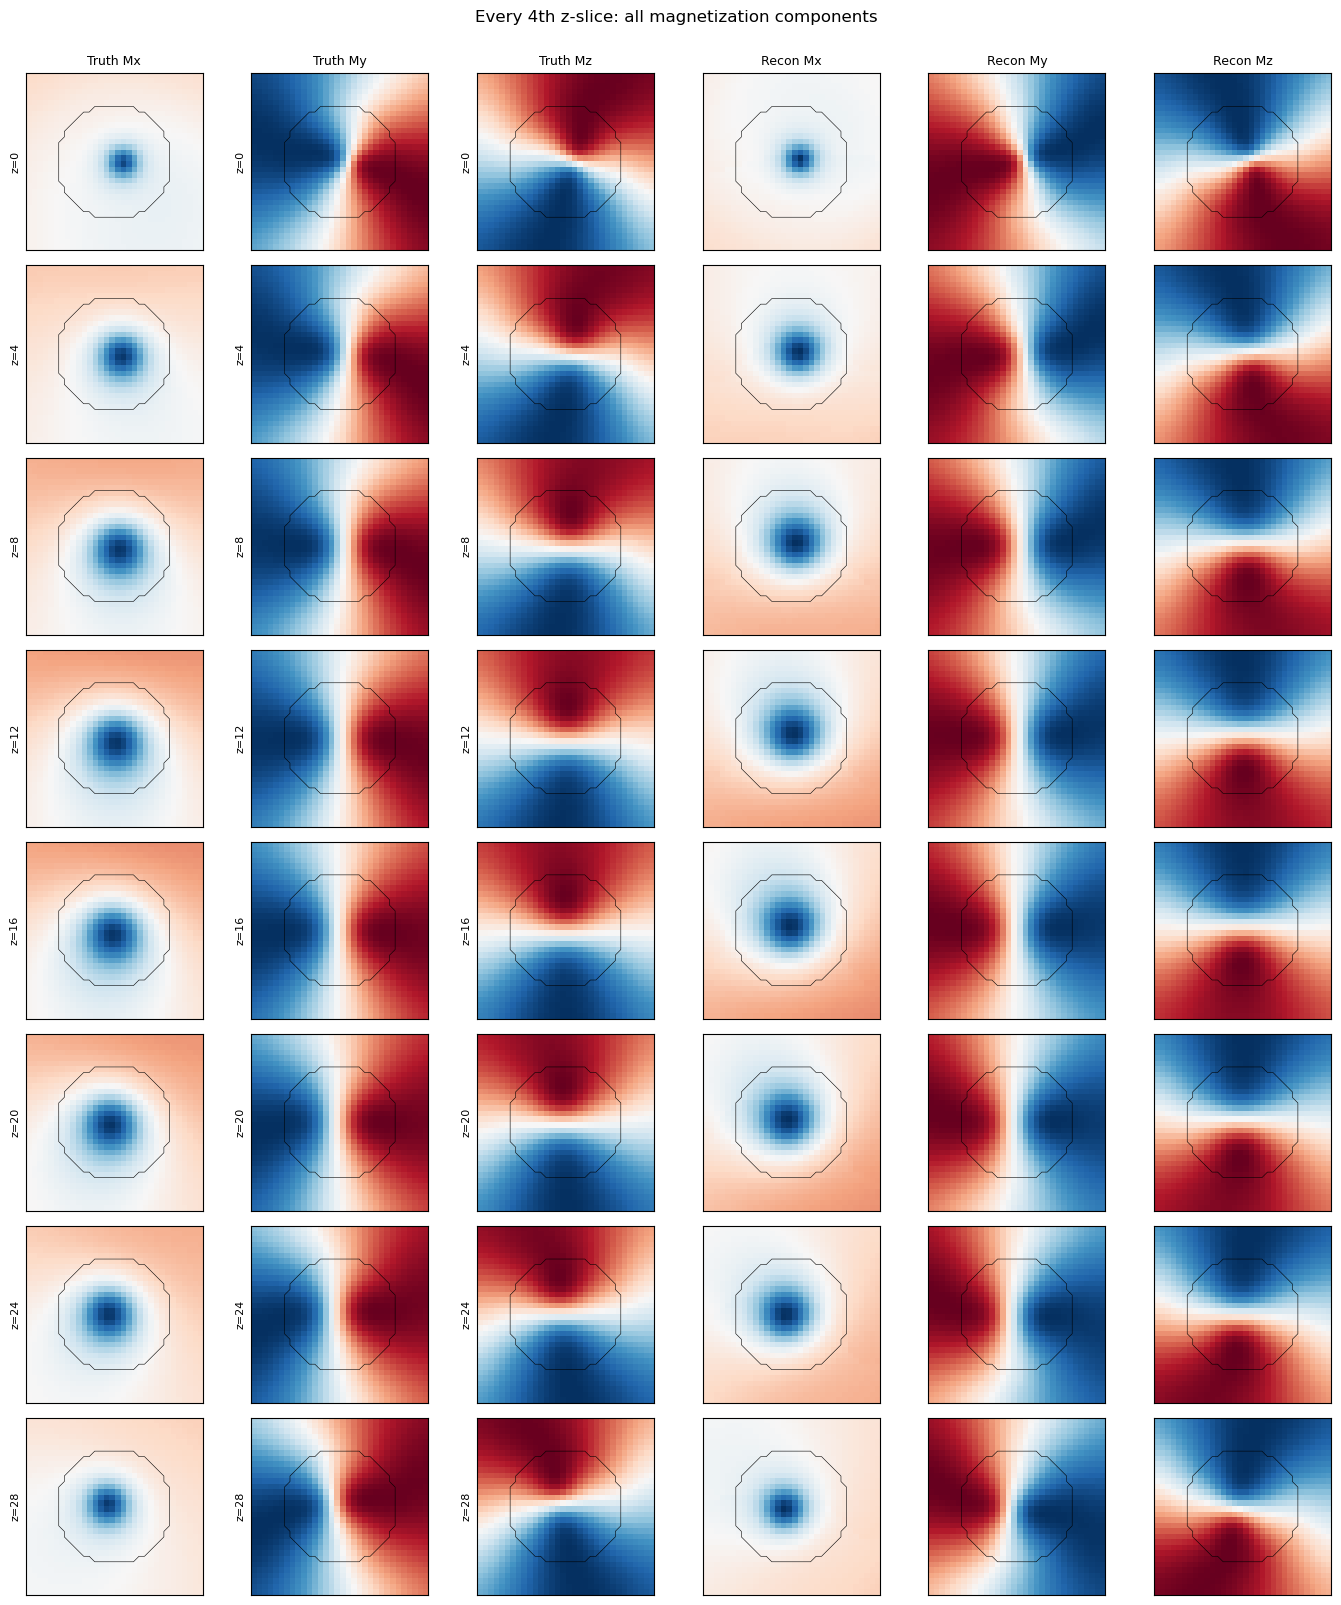

In [15]:
# Every 4th z-slice for all magnetization components: truth vs reconstruction.
m_recon = chosen_result.get('m_recon')
slice_indices = list(range(0, m_true.shape[0], 4))
components = [(0, 'Mx'), (1, 'My'), (2, 'Mz')]
n_rows = len(slice_indices)
n_cols = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.3 * n_cols, 2.0 * n_rows), squeeze=False)
for row_idx, z_idx in enumerate(slice_indices):
    support_2d = rho_true[z_idx] > 0.5
    for comp_offset, (comp_idx, comp_name) in enumerate(components):
        true_ax = axes[row_idx, comp_offset]
        recon_ax = axes[row_idx, comp_offset + 3]
        true_im = true_ax.imshow(m_true[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
        recon_im = recon_ax.imshow(m_recon[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
        true_ax.contour(support_2d, levels=[0.5], colors='k', linewidths=0.4)
        recon_ax.contour(support_2d, levels=[0.5], colors='k', linewidths=0.4)
        if row_idx == 0:
            true_ax.set_title(f'Truth {comp_name}', fontsize=9)
            recon_ax.set_title(f'Recon {comp_name}', fontsize=9)
        true_ax.set_ylabel(f'z={z_idx}', fontsize=8)
        true_ax.set_xticks([])
        true_ax.set_yticks([])
        recon_ax.set_xticks([])
        recon_ax.set_yticks([])
plt.suptitle('Every 4th z-slice: all magnetization components', y=1.0)
plt.tight_layout()
plt.show()

## Short conclusion
Setting `projection_threshold = 0.00` (allowing reconstruction in the density ramp and outside the hard mask) is the primary empirical change that improved reconstruction metrics in the PP-B schedule on the cached 32^3 vortex-disc fixture. See `06_physics_projected.ipynb` for the full experiment and saved artifacts.